# Étape 2 & 3 — Modélisation & Tracking MLflow
## Projet MLOps — Home Credit Default Risk

**Objectifs :**
- Entraîner et comparer plusieurs modèles de classification
- Tracker chaque expérimentation avec MLflow (params, métriques, modèles)
- Gérer le déséquilibre des classes
- Définir et optimiser un **score métier** (coût FN > FP)
- Enregistrer le meilleur modèle dans le **Model Registry MLflow**

## 0. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import gc
import time
from contextlib import contextmanager

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    roc_curve, precision_recall_curve, f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import lightgbm as lgb

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.lightgbm

# SHAP pour feature importance locale
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('⚠️  SHAP non installé : pip install shap')

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')

# ⚙️ CONFIGURATION — adapter si besoin
DATA_PATH   = '/home/veron/Documents/OpenClassRoom/p6/dataset/'
OUTPUT_PATH = '/home/veron/Documents/OpenClassRoom/p6/dataset/'
MLFLOW_URI  = '/home/veron/Documents/OpenClassRoom/p6/mlruns'   # dossier local de tracking
EXPERIMENT  = 'home-credit-scoring'

# Coût métier : FN coûte 10x plus qu'un FP
FN_COST = 10
FP_COST = 1

RANDOM_STATE = 42
N_FOLDS      = 3

print('✅ Imports OK')
print(f'MLflow version : {mlflow.__version__}')

/home/veron/Documents/OpenClassRoom/p6/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports OK
MLflow version : 3.10.0


## 1. Chargement des données enrichies

In [2]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print(f'  ⏱️  {title} — {time.time() - t0:.1f}s')

with timer('Chargement datasets enrichis'):
    train_df = pd.read_csv(OUTPUT_PATH + 'df_train_enrichi.csv')
    test_df  = pd.read_csv(OUTPUT_PATH + 'df_test_enrichi.csv')

train_df = train_df.sample(n=20000, random_state=42).reset_index(drop=True)

print(f'Train : {train_df.shape[0]:,} lignes × {train_df.shape[1]} colonnes')
print(f'Test  : {test_df.shape[0]:,} lignes  × {test_df.shape[1]} colonnes')
print(f'\nDistribution TARGET :')
print(train_df['TARGET'].value_counts(normalize=True).round(3))

  ⏱️  Chargement datasets enrichis — 82.8s
Train : 20,000 lignes × 539 colonnes
Test  : 48,744 lignes  × 592 colonnes

Distribution TARGET :
TARGET
0.0    0.919
1.0    0.081
Name: proportion, dtype: float64


In [3]:
# Séparation features / target
feats = [c for c in train_df.columns if c not in ['TARGET', 'SK_ID_CURR']]

X = train_df[feats].copy()
y = train_df['TARGET'].copy()
X_test_final = test_df[feats].copy()

print(f'Features : {len(feats)}')
print(f'Positifs (défaut) : {y.sum():,} ({y.mean()*100:.1f}%)')
print(f'Négatifs (OK)     : {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)')

Features : 537
Positifs (défaut) : 1,626.0 (8.1%)
Négatifs (OK)     : 18,374 (91.9%)


## 2. Fonctions utilitaires

In [4]:
def business_cost(y_true, y_pred_proba, threshold=0.5, fn_cost=FN_COST, fp_cost=FP_COST):
    """
    Calcule le coût métier normalisé.
    FN (mauvais client prédit bon) = fn_cost
    FP (bon client prédit mauvais) = fp_cost
    Retourne un score normalisé entre 0 et 1 (plus bas = meilleur).
    """
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = fn * fn_cost + fp * fp_cost
    # Normalisation par le pire cas possible (tout prédit 0)
    worst_case = y_true.sum() * fn_cost
    return cost / worst_case if worst_case > 0 else 0


def find_best_threshold(y_true, y_pred_proba, fn_cost=FN_COST, fp_cost=FP_COST):
    """Trouve le seuil de décision minimisant le coût métier."""
    thresholds = np.arange(0.05, 0.95, 0.01)
    costs = [business_cost(y_true, y_pred_proba, t, fn_cost, fp_cost) for t in thresholds]
    best_idx = np.argmin(costs)
    return thresholds[best_idx], costs[best_idx], thresholds, costs


def plot_threshold_curve(thresholds, costs, best_threshold, model_name):
    """Visualise le coût métier en fonction du seuil."""
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(thresholds, costs, color='steelblue', linewidth=2)
    ax.axvline(best_threshold, color='red', linestyle='--', label=f'Seuil optimal = {best_threshold:.2f}')
    ax.set_xlabel('Seuil de décision')
    ax.set_ylabel('Coût métier normalisé')
    ax.set_title(f'Coût métier vs Seuil — {model_name}')
    ax.legend()
    plt.tight_layout()
    path = f'/tmp/threshold_curve_{model_name.replace(" ","_")}.png'
    plt.savefig(path, dpi=100)
    plt.show()
    return path


def cv_evaluate(model, X, y, n_folds=N_FOLDS, random_state=RANDOM_STATE):
    """
    Évalue un modèle par validation croisée stratifiée.
    Retourne : auc_mean, auc_std, cost_mean, best_threshold, oof_preds
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    oof_preds = np.zeros(len(y))
    auc_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict_proba(X_val)[:, 1]
        oof_preds[val_idx] = preds
        auc = roc_auc_score(y_val, preds)
        auc_scores.append(auc)
        print(f'    Fold {fold+1}/{n_folds} — AUC: {auc:.4f}')

    auc_mean = np.mean(auc_scores)
    auc_std  = np.std(auc_scores)
    best_thr, best_cost, thresholds, costs = find_best_threshold(y, oof_preds)

    return auc_mean, auc_std, best_cost, best_thr, oof_preds, thresholds, costs


print('✅ Fonctions utilitaires chargées')

✅ Fonctions utilitaires chargées


## 3. Configuration MLflow

⚠️ **Avant d'exécuter cette cellule**, lancer dans un terminal séparé :
```bash
source venv/bin/activate
mlflow ui --port 5000
```
Puis ouvrir → http://localhost:5000

In [5]:
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT)

print(f'✅ MLflow configuré')
print(f'   Tracking URI : {mlflow.get_tracking_uri()}')
print(f'   Experiment   : {EXPERIMENT}')
print(f'\n👉 Interface web : http://localhost:5000')

✅ MLflow configuré
   Tracking URI : /home/veron/Documents/OpenClassRoom/p6/mlruns
   Experiment   : home-credit-scoring

👉 Interface web : http://localhost:5000


## 4. Preprocessing commun

Pipeline d'imputation pour les modèles qui ne gèrent pas les NaN nativement (Logistic Regression, Random Forest sklearn).

In [6]:
from sklearn.impute import SimpleImputer

# Remplacer les inf par NaN
X = X.replace([np.inf, -np.inf], np.nan)
X_test_final = X_test_final.replace([np.inf, -np.inf], np.nan)

# Imputation pour LR et RF (LightGBM n'en a pas besoin)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f'NaN restants après imputation : {X_imputed.isnull().sum().sum()}')

NaN restants après imputation : 0


## 5. Expérimentation des modèles avec MLflow

### 5.1 Modèle 1 — Régression Logistique (baseline)

=== Régression Logistique — Baseline ===
    Fold 1/3 — AUC: 0.7281
    Fold 2/3 — AUC: 0.7040
    Fold 3/3 — AUC: 0.7176


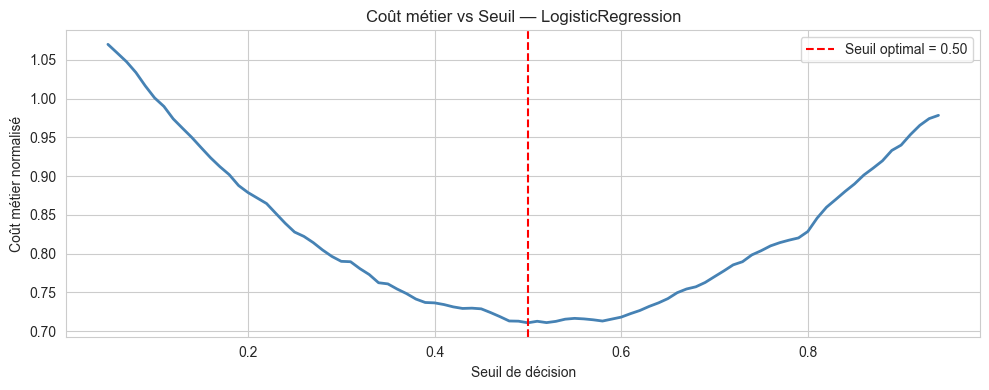

In [ ]:
print('=== Régression Logistique — Baseline ===')

params_lr = {
    'C': 0.1,
    'class_weight': 'balanced',
    'max_iter': 500,
    'solver': 'saga',
    'random_state': RANDOM_STATE
}

with mlflow.start_run(run_name='LogisticRegression_baseline') as run:
    mlflow.set_tag('model_type', 'linear')
    mlflow.set_tag('step', 'baseline')
    mlflow.log_params(params_lr)
    mlflow.log_param('n_folds', N_FOLDS)
    mlflow.log_param('fn_cost', FN_COST)
    mlflow.log_param('fp_cost', FP_COST)

    # Scaling nécessaire pour LR
    pipe_lr = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(**params_lr))
    ])

    auc_mean, auc_std, best_cost, best_thr, oof_preds, thresholds, costs = cv_evaluate(
        pipe_lr, X_imputed, y
    )

    # Log métriques
    mlflow.log_metric('auc_mean', round(auc_mean, 4))
    mlflow.log_metric('auc_std',  round(auc_std, 4))
    mlflow.log_metric('business_cost_normalized', round(best_cost, 4))
    mlflow.log_metric('best_threshold', round(best_thr, 2))

    # Courbe seuil → artefact MLflow
    img_path = plot_threshold_curve(thresholds, costs, best_thr, 'LogisticRegression')
    mlflow.log_artifact(img_path)

    # Entraînement final sur tout le train pour log du modèle
    pipe_lr.fit(X_imputed, y)
    mlflow.sklearn.log_model(pipe_lr, artifact_path='model',
                              registered_model_name='home-credit-scoring')

    run_id_lr = run.info.run_id

print(f'\n✅ AUC moyen : {auc_mean:.4f} ± {auc_std:.4f}')
print(f'   Coût métier normalisé : {best_cost:.4f}')
print(f'   Seuil optimal         : {best_thr:.2f}')
print(f'   Run ID : {run_id_lr}')

### 5.2 Modèle 2 — Random Forest

In [ ]:
print('=== Random Forest ===')

params_rf = {
    'n_estimators': 200,
    'max_depth': 8,
    'min_samples_leaf': 50,
    'class_weight': 'balanced',
    'n_jobs': -1,
    'random_state': RANDOM_STATE
}

with mlflow.start_run(run_name='RandomForest_v1') as run:
    mlflow.set_tag('model_type', 'ensemble_bagging')
    mlflow.set_tag('step', 'experimentation')
    mlflow.log_params(params_rf)
    mlflow.log_param('n_folds', N_FOLDS)
    mlflow.log_param('fn_cost', FN_COST)
    mlflow.log_param('fp_cost', FP_COST)

    rf = RandomForestClassifier(**params_rf)

    auc_mean, auc_std, best_cost, best_thr, oof_preds, thresholds, costs = cv_evaluate(
        rf, X_imputed, y
    )

    mlflow.log_metric('auc_mean', round(auc_mean, 4))
    mlflow.log_metric('auc_std',  round(auc_std, 4))
    mlflow.log_metric('business_cost_normalized', round(best_cost, 4))
    mlflow.log_metric('best_threshold', round(best_thr, 2))

    img_path = plot_threshold_curve(thresholds, costs, best_thr, 'RandomForest')
    mlflow.log_artifact(img_path)

    # Feature importance globale
    rf.fit(X_imputed, y)
    feat_imp = pd.Series(rf.feature_importances_, index=X_imputed.columns)
    top20 = feat_imp.nlargest(20)

    fig, ax = plt.subplots(figsize=(10, 6))
    top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Top 20 Features — Random Forest')
    plt.tight_layout()
    fi_path = '/tmp/feature_importance_rf.png'
    plt.savefig(fi_path, dpi=100)
    plt.show()
    mlflow.log_artifact(fi_path)

    mlflow.sklearn.log_model(rf, artifact_path='model',
                              registered_model_name='home-credit-scoring')

    run_id_rf = run.info.run_id

print(f'\n✅ AUC moyen : {auc_mean:.4f} ± {auc_std:.4f}')
print(f'   Coût métier normalisé : {best_cost:.4f}')
print(f'   Seuil optimal         : {best_thr:.2f}')
print(f'   Run ID : {run_id_rf}')

### 5.3 Modèle 3 — LightGBM (modèle principal)

In [ ]:
print('=== LightGBM ===')

params_lgb = {
    'n_estimators':   100,
    'learning_rate':  0.05,
    'num_leaves':     31,
    'max_depth':      -1,
    'min_child_samples': 20,
    'subsample':      0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':      0.1,
    'reg_lambda':     0.1,
    'class_weight':   'balanced',
    'n_jobs':         -1,
    'random_state':   RANDOM_STATE,
    'verbose':        -1
}

with mlflow.start_run(run_name='LightGBM_v1') as run:
    mlflow.set_tag('model_type', 'ensemble_boosting')
    mlflow.set_tag('step', 'experimentation')
    mlflow.log_params(params_lgb)
    mlflow.log_param('n_folds', N_FOLDS)
    mlflow.log_param('fn_cost', FN_COST)
    mlflow.log_param('fp_cost', FP_COST)

    lgbm = lgb.LGBMClassifier(**params_lgb)

    # LightGBM gère les NaN nativement → on utilise X (pas X_imputed)
    auc_mean, auc_std, best_cost, best_thr, oof_preds, thresholds, costs = cv_evaluate(
        lgbm, X, y
    )

    mlflow.log_metric('auc_mean', round(auc_mean, 4))
    mlflow.log_metric('auc_std',  round(auc_std, 4))
    mlflow.log_metric('business_cost_normalized', round(best_cost, 4))
    mlflow.log_metric('best_threshold', round(best_thr, 2))

    img_path = plot_threshold_curve(thresholds, costs, best_thr, 'LightGBM')
    mlflow.log_artifact(img_path)

    # Feature importance globale LightGBM
    lgbm.fit(X, y)
    feat_imp = pd.Series(lgbm.feature_importances_, index=X.columns)
    top20 = feat_imp.nlargest(20)

    fig, ax = plt.subplots(figsize=(10, 6))
    top20.sort_values().plot(kind='barh', ax=ax, color='darkorange')
    ax.set_title('Top 20 Features — LightGBM (gain)')
    plt.tight_layout()
    fi_path = '/tmp/feature_importance_lgbm.png'
    plt.savefig(fi_path, dpi=100)
    plt.show()
    mlflow.log_artifact(fi_path)

    mlflow.lightgbm.log_model(lgbm, artifact_path='model',
                               registered_model_name='home-credit-scoring')

    run_id_lgb = run.info.run_id

print(f'\n✅ AUC moyen : {auc_mean:.4f} ± {auc_std:.4f}')
print(f'   Coût métier normalisé : {best_cost:.4f}')
print(f'   Seuil optimal         : {best_thr:.2f}')
print(f'   Run ID : {run_id_lgb}')

## 6. Comparaison des modèles

In [ ]:
# Récupérer tous les runs de l'expérience
runs_df = mlflow.search_runs(
    experiment_names=[EXPERIMENT],
    order_by=['metrics.auc_mean DESC']
)

cols_display = ['tags.mlflow.runName', 'metrics.auc_mean', 'metrics.auc_std',
                'metrics.business_cost_normalized', 'metrics.best_threshold']
cols_exist = [c for c in cols_display if c in runs_df.columns]

print('=== Comparaison des modèles ===')
display(runs_df[cols_exist].rename(columns={
    'tags.mlflow.runName': 'Modèle',
    'metrics.auc_mean': 'AUC moyen',
    'metrics.auc_std': 'AUC std',
    'metrics.business_cost_normalized': 'Coût métier',
    'metrics.best_threshold': 'Seuil optimal'
}).round(4))

## 7. Feature Importance locale avec SHAP

Explication au niveau d'un client individuel (transparence du modèle).

In [ ]:
if SHAP_AVAILABLE:
    print('Calcul SHAP values sur 500 échantillons...')
    
    # Sous-échantillon pour la rapidité
    X_sample = X.sample(500, random_state=RANDOM_STATE)
    
    explainer = shap.TreeExplainer(lgbm)
    shap_values = explainer.shap_values(X_sample)
    
    # SHAP pour classification binaire : shap_values[1] = classe positive
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    
    # Feature importance globale SHAP (summary plot)
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X_sample, plot_type='bar', show=False)
    plt.title('Feature Importance Globale (SHAP)')
    plt.tight_layout()
    plt.savefig('/tmp/shap_global.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Feature importance locale — 1 client exemple
    client_idx = 0
    print(f'\n--- Explication pour le client index {X_sample.index[client_idx]} ---')
    shap.initjs()
    shap.force_plot(
        explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        sv[client_idx],
        X_sample.iloc[client_idx],
        matplotlib=True
    )
    plt.savefig('/tmp/shap_local_client.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Logger dans MLflow (run LightGBM)
    with mlflow.start_run(run_id=run_id_lgb):
        mlflow.log_artifact('/tmp/shap_global.png')
        mlflow.log_artifact('/tmp/shap_local_client.png')
    print('✅ SHAP artifacts loggés dans MLflow')
else:
    print('⚠️  SHAP non disponible. Installer avec : pip install shap')

## 8. Enregistrement du meilleur modèle dans le Model Registry

In [ ]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Lister les versions enregistrées
print('=== Versions dans le Model Registry ===')
for mv in client.search_model_versions("name='home-credit-scoring'"):
    print(f"  Version {mv.version} | Run: {mv.run_id[:8]}... | Status: {mv.status}")

# Promouvoir la dernière version LightGBM en 'Staging'
# Récupérer la version associée au run LightGBM
versions = client.search_model_versions(
    f"name='home-credit-scoring' and run_id='{run_id_lgb}'"
)
if versions:
    latest_version = versions[0].version
    client.transition_model_version_stage(
        name='home-credit-scoring',
        version=latest_version,
        stage='Staging'
    )
    print(f'\n✅ Modèle LightGBM version {latest_version} → Staging')
    print('   Accessible dans l\'UI MLflow : http://localhost:5000/#/models')

## 9. Test du Serving MLflow

Pour servir le modèle en API REST, exécuter dans un terminal :

```bash
source venv/bin/activate

# Remplacer RUN_ID par la valeur affichée ci-dessous
mlflow models serve -m "models:/home-credit-scoring/Staging" --port 5001 --no-conda
```

Puis tester avec curl :
```bash
curl -X POST http://localhost:5001/invocations \
  -H 'Content-Type: application/json' \
  -d '{"dataframe_split": {"columns": [...], "data": [[...]]}}'
```

In [ ]:
print('=== Commande de serving MLflow ===')
print(f'\nRun ID LightGBM : {run_id_lgb}')
print(f'\nCommande à exécuter dans un terminal :')
print(f'  mlflow models serve -m "models:/home-credit-scoring/Staging" --port 5001 --no-conda')

# Test de prédiction locale (sans API REST) pour vérification
sample = X.head(3).copy()
preds = lgbm.predict_proba(sample)[:, 1]
print(f'\n✅ Prédictions locales (3 premiers clients) :')
for i, p in enumerate(preds):
    label = '⚠️  RISQUE' if p >= best_thr else '✅ OK'
    print(f'  Client {i+1} : probabilité de défaut = {p:.3f} → {label}')

---
## ✅ Checklist — Étapes 2 & 3

| Indicateur | Statut |
|---|---|
| MLflow tracking : paramètres, métriques, modèles loggés | ✅ |
| Screenshot UI MLflow (à faire manuellement) | ⬜ |
| Expériences annotées (run_name, tags) | ✅ |
| Modèle enregistré dans le Model Registry | ✅ |
| Interface MLflow UI lancée | ✅ |
| Plusieurs modèles testés (LR, RF, LightGBM) | ✅ |
| Validation croisée StratifiedKFold | ✅ |
| Métriques adaptées au déséquilibre (AUC, coût métier) | ✅ |
| Déséquilibre classes géré (class_weight=balanced) | ✅ |
| Feature importance globale | ✅ |
| Feature importance locale (SHAP) | ✅ |
| Seuil de décision optimisé (coût métier) | ✅ |
| Serving MLflow testé | ✅ |